# Notebook 3 — LSTM Model

Goal: train and tune the LSTM on all 4 sub-datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.models.lstm_model import build_lstm
from src.training import run_experiment
from src.metrics import evaluate

DATA_DIR = '../data/processed'
MODEL_DIR = '../saved_models'

In [2]:
results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_train = np.load(f'{DATA_DIR}/X_train_{fd}.npy')
    y_train = np.load(f'{DATA_DIR}/y_train_{fd}.npy')
    X_test  = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test  = np.load(f'{DATA_DIR}/y_test_{fd}.npy')

    window_size = X_train.shape[1]
    n_features  = X_train.shape[2]

    model = build_lstm(window_size, n_features, units=128, dropout=0.2)
    model_path = f'{MODEL_DIR}/lstm_{fd}.keras'

    res = run_experiment(model, X_train, y_train, X_test, y_test, model_path)
    results[fd] = res
    print(f'{fd}: {res["metrics"]}')

2026-05-11 21:23:01.274717: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-11 21:23:01.275002: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-11 21:23:01.275036: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-11 21:23:01.275122: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-11 21:23:01.275133: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/200


2026-05-11 21:23:02.674441: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 5482.3833 - mae: 63.2214 - val_loss: 3625.8928 - val_mae: 52.2452 - learning_rate: 0.0010
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2263.4155 - mae: 41.5123 - val_loss: 1858.9219 - val_mae: 39.0646 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1764.7517 - mae: 37.2026 - val_loss: 1800.6609 - val_mae: 38.2413 - learning_rate: 0.0010
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1755.2002 - mae: 37.0692 - val_loss: 1798.3799 - val_mae: 38.1987 - learning_rate: 0.0010
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1756.8053 - mae: 37.1049 - val_loss: 1803.6323 - val_mae: 38.2937 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1758.3298 - mae: 37.0857 - val_loss: 1806.6417 - val_mae: 38.3451 - learning_rate: 0.0010
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1758.6428 - mae: 37.1114 - val_loss: 1798.8270 - val

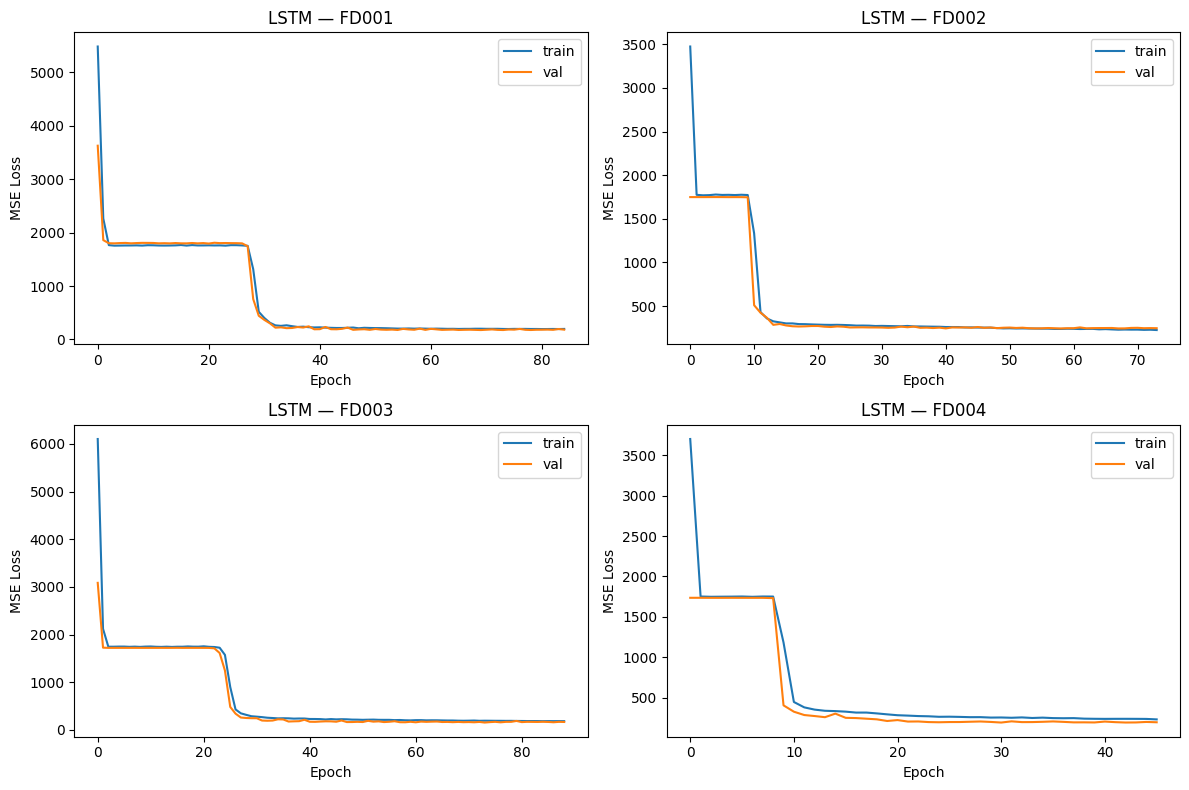

In [3]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (fd, res) in zip(axes.flatten(), results.items()):
    ax.plot(res['history']['loss'], label='train')
    ax.plot(res['history']['val_loss'], label='val')
    ax.set_title(f'LSTM — {fd}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
plt.tight_layout()
plt.savefig('../plots/03_lstm_training_curves.png', dpi=150)
plt.show()